In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"

print("Results directory:", RESULTS_DIR)

Results directory: c:\Users\arvin\Desktop\projects\adversarial-ids\experiments\results


In [2]:
fgsm_results = pd.read_csv(
    RESULTS_DIR / "fgsm_results.csv"
)

pgd_results = pd.read_csv(
    RESULTS_DIR / "pgd_results.csv"
)

robustness_results = pd.read_csv(
    RESULTS_DIR / "robustness_evaluation.csv"
)

final_test_results = pd.read_csv(
    RESULTS_DIR / "final_test_results.csv"
)

print("FGSM:", fgsm_results.shape)
print("PGD:", pgd_results.shape)
print("Robustness:", robustness_results.shape)
print("Final test:", final_test_results.shape)

FGSM: (5, 14)
PGD: (5, 16)
Robustness: (20, 17)
Final test: (6, 15)


In [3]:
final_test_results[
    [
        "Model",
        "Condition",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "FPR",
        "FNR",
        "Attack Success Rate"
    ]
]

,Model,Condition,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FPR,FNR,Attack Success Rate
0,Baseline NN,Clean,0.983846,0.961293,0.942297,0.951700,0.998678,0.993938,0.007710,0.057703,NaN
1,Baseline NN,FGSM,0.894258,0.679528,0.707631,0.693295,0.952711,0.827534,0.067817,0.292369,0.249036
2,Baseline NN,PGD,0.893074,0.675222,0.706910,0.690703,0.951881,0.825259,0.069096,0.293090,0.249801
3,Adversarially Trained NN,Clean,0.981604,0.972264,0.917242,0.943952,0.998419,0.992875,0.005317,0.082758,NaN
4,Adversarially Trained NN,FGSM,0.977761,0.957389,0.908771,0.932446,0.997354,0.988483,0.008219,0.091229,0.009236
5,Adversarially Trained NN,PGD,0.977684,0.956976,0.908724,0.932226,0.997160,0.987686,0.008302,0.091276,0.009287


In [4]:
baseline_fgsm = final_test_results[
    (final_test_results["Model"] == "Baseline NN") &
    (final_test_results["Condition"] == "FGSM")
].iloc[0]

adv_fgsm = final_test_results[
    (final_test_results["Model"] == "Adversarially Trained NN") &
    (final_test_results["Condition"] == "FGSM")
].iloc[0]

baseline_pgd = final_test_results[
    (final_test_results["Model"] == "Baseline NN") &
    (final_test_results["Condition"] == "PGD")
].iloc[0]

adv_pgd = final_test_results[
    (final_test_results["Model"] == "Adversarially Trained NN") &
    (final_test_results["Condition"] == "PGD")
].iloc[0]

In [5]:
fgsm_asr_absolute_reduction = (
    baseline_fgsm["Attack Success Rate"]
    - adv_fgsm["Attack Success Rate"]
)

pgd_asr_absolute_reduction = (
    baseline_pgd["Attack Success Rate"]
    - adv_pgd["Attack Success Rate"]
)

fgsm_asr_relative_reduction = (
    fgsm_asr_absolute_reduction /
    baseline_fgsm["Attack Success Rate"]
) * 100

pgd_asr_relative_reduction = (
    pgd_asr_absolute_reduction /
    baseline_pgd["Attack Success Rate"]
) * 100

print(
    "FGSM absolute ASR reduction:",
    fgsm_asr_absolute_reduction
)

print(
    "FGSM relative ASR reduction:",
    fgsm_asr_relative_reduction,
    "%"
)

print(
    "PGD absolute ASR reduction:",
    pgd_asr_absolute_reduction
)

print(
    "PGD relative ASR reduction:",
    pgd_asr_relative_reduction,
    "%"
)

FGSM absolute ASR reduction: 0.23980029607769499
FGSM relative ASR reduction: 96.29135604411702 %
PGD absolute ASR reduction: 0.240513504918033
PGD relative ASR reduction: 96.28220244776182 %


In [6]:
baseline_clean = final_test_results[
    (final_test_results["Model"] == "Baseline NN") &
    (final_test_results["Condition"] == "Clean")
].iloc[0]

adv_clean = final_test_results[
    (final_test_results["Model"] == "Adversarially Trained NN") &
    (final_test_results["Condition"] == "Clean")
].iloc[0]

In [7]:
baseline_fgsm_recall_drop = (
    baseline_clean["Recall"]
    - baseline_fgsm["Recall"]
)

baseline_pgd_recall_drop = (
    baseline_clean["Recall"]
    - baseline_pgd["Recall"]
)

adv_fgsm_recall_drop = (
    adv_clean["Recall"]
    - adv_fgsm["Recall"]
)

adv_pgd_recall_drop = (
    adv_clean["Recall"]
    - adv_pgd["Recall"]
)

print(
    "Baseline FGSM recall drop:",
    baseline_fgsm_recall_drop
)

print(
    "Baseline PGD recall drop:",
    baseline_pgd_recall_drop
)

print(
    "Adv-trained FGSM recall drop:",
    adv_fgsm_recall_drop
)

print(
    "Adv-trained PGD recall drop:",
    adv_pgd_recall_drop
)

Baseline FGSM recall drop: 0.23466591503421497
Baseline PGD recall drop: 0.23538622946712395
Adv-trained FGSM recall drop: 0.008471524091385962
Adv-trained PGD recall drop: 0.00851850111961916


In [8]:
research_summary = pd.DataFrame([
    {
        "Model": "Baseline NN",
        "Clean Recall": baseline_clean["Recall"],
        "FGSM Recall": baseline_fgsm["Recall"],
        "PGD Recall": baseline_pgd["Recall"],
        "FGSM ASR": baseline_fgsm["Attack Success Rate"],
        "PGD ASR": baseline_pgd["Attack Success Rate"],
        "Clean FNR": baseline_clean["FNR"],
        "FGSM FNR": baseline_fgsm["FNR"],
        "PGD FNR": baseline_pgd["FNR"]
    },
    {
        "Model": "Adversarially Trained NN",
        "Clean Recall": adv_clean["Recall"],
        "FGSM Recall": adv_fgsm["Recall"],
        "PGD Recall": adv_pgd["Recall"],
        "FGSM ASR": adv_fgsm["Attack Success Rate"],
        "PGD ASR": adv_pgd["Attack Success Rate"],
        "Clean FNR": adv_clean["FNR"],
        "FGSM FNR": adv_fgsm["FNR"],
        "PGD FNR": adv_pgd["FNR"]
    }
])

research_summary

,Model,Clean Recall,FGSM Recall,PGD Recall,FGSM ASR,PGD ASR,Clean FNR,FGSM FNR,PGD FNR
0,Baseline NN,0.942297,0.707631,0.706910,0.249036,0.249801,0.057703,0.292369,0.293090
1,Adversarially Trained NN,0.917242,0.908771,0.908724,0.009236,0.009287,0.082758,0.091229,0.091276


In [9]:
research_summary.to_csv(
    RESULTS_DIR / "final_research_summary.csv",
    index=False
)

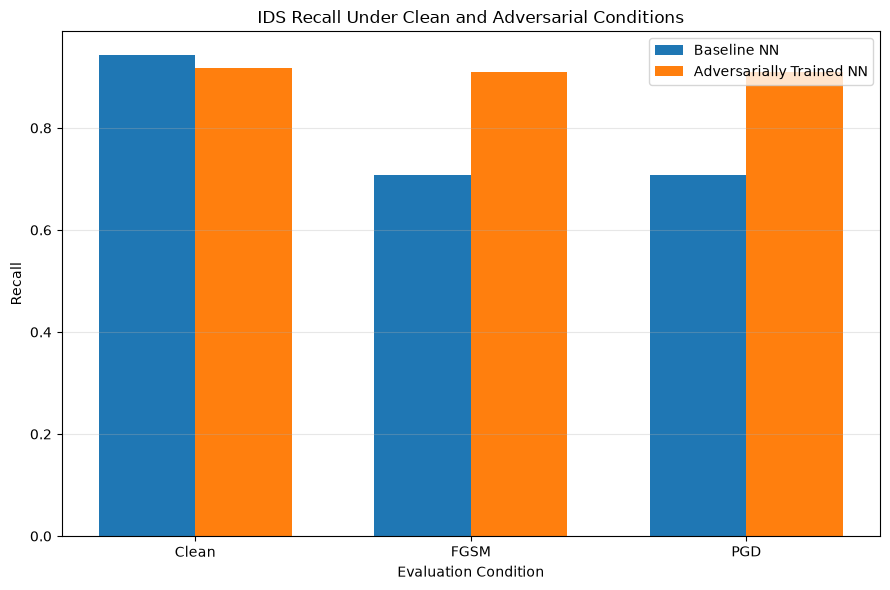

In [10]:
import matplotlib.pyplot as plt

conditions = [
    "Clean",
    "FGSM",
    "PGD"
]

baseline_recall = [
    baseline_clean["Recall"],
    baseline_fgsm["Recall"],
    baseline_pgd["Recall"]
]

adv_recall = [
    adv_clean["Recall"],
    adv_fgsm["Recall"],
    adv_pgd["Recall"]
]

x = np.arange(len(conditions))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    baseline_recall,
    width,
    label="Baseline NN"
)

plt.bar(
    x + width / 2,
    adv_recall,
    width,
    label="Adversarially Trained NN"
)

plt.xticks(x, conditions)
plt.ylabel("Recall")
plt.xlabel("Evaluation Condition")
plt.title("IDS Recall Under Clean and Adversarial Conditions")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "final_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

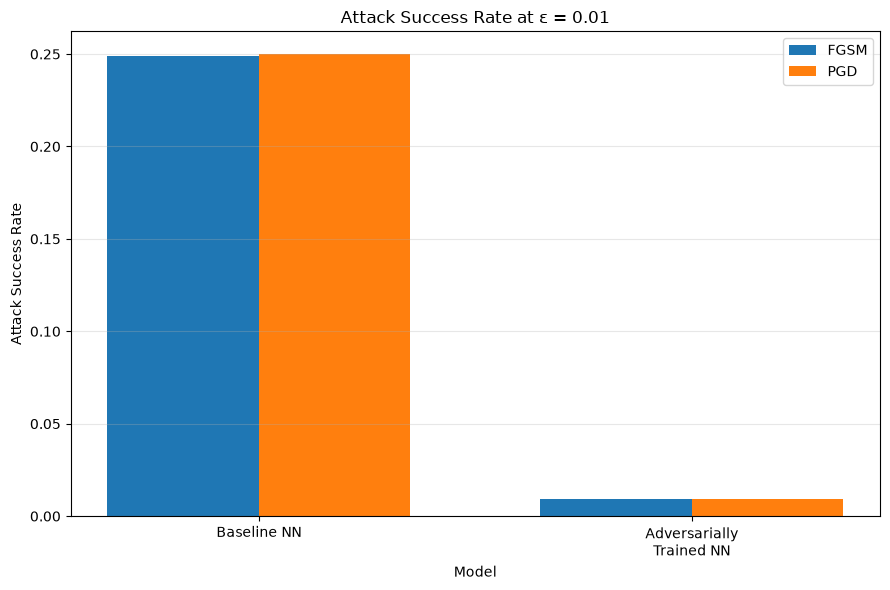

In [11]:
fgsm_asr_values = [
    baseline_fgsm["Attack Success Rate"],
    adv_fgsm["Attack Success Rate"]
]

pgd_asr_values = [
    baseline_pgd["Attack Success Rate"],
    adv_pgd["Attack Success Rate"]
]

models = [
    "Baseline NN",
    "Adversarially\nTrained NN"
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    fgsm_asr_values,
    width,
    label="FGSM"
)

plt.bar(
    x + width / 2,
    pgd_asr_values,
    width,
    label="PGD"
)

plt.xticks(x, models)
plt.ylabel("Attack Success Rate")
plt.xlabel("Model")
plt.title("Attack Success Rate at ε = 0.01")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "final_asr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

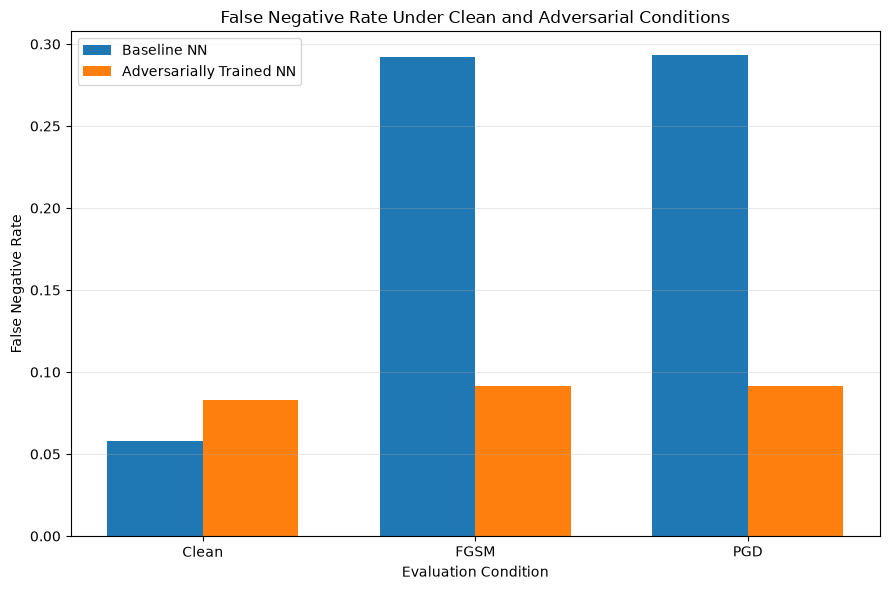

In [12]:
baseline_fnr = [
    baseline_clean["FNR"],
    baseline_fgsm["FNR"],
    baseline_pgd["FNR"]
]

adv_fnr = [
    adv_clean["FNR"],
    adv_fgsm["FNR"],
    adv_pgd["FNR"]
]

x = np.arange(len(conditions))

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    baseline_fnr,
    width,
    label="Baseline NN"
)

plt.bar(
    x + width / 2,
    adv_fnr,
    width,
    label="Adversarially Trained NN"
)

plt.xticks(x, conditions)
plt.ylabel("False Negative Rate")
plt.xlabel("Evaluation Condition")
plt.title("False Negative Rate Under Clean and Adversarial Conditions")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "final_fnr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()